# 探索心率数据
1. 读取原始数据
2. 寻找峰值
3. 计算心率
4. 计算SDNN
5. 对数据进行傅立叶变化
6. 绘制傅立叶变化后的图形

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats
from scipy import signal

In [2]:
## 确定文件兰蔻
data_path = "/Users/wangshuaibo/Documents/ScriptsofShuai/Notes/ExampleData/2024-07-02_10-01-28_ECG-data_polarH10_siting_6_minutes.txt"

In [3]:
## 读取数据
df = pd.read_csv(data_path,header=None) #跳过表头
df.columns = ["Voltage"] #为数据增加标题为「电压」

# 查看数据详情
df.describe() 


,Voltage
count,46866.000000
mean,56.955149
std,445.269096
min,-516.000000
25%,-72.000000
50%,-7.000000
75%,56.000000
max,9874.000000


In [4]:
# 计算采样频率
df.count()/(6*60) #采样频率为 130.183 HZ

Voltage    130.183333
dtype: float64

<Axes: >

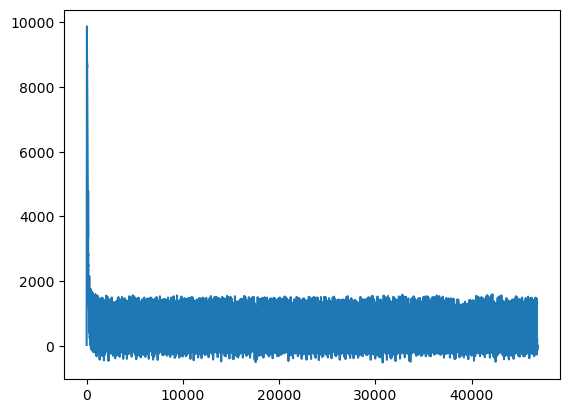

In [5]:
## 绘制心电图数据
df["Voltage"].plot()

In [6]:
## 数据处理：去除前 1 分钟的数据
df_trim = df[7800:-1]

<Axes: >

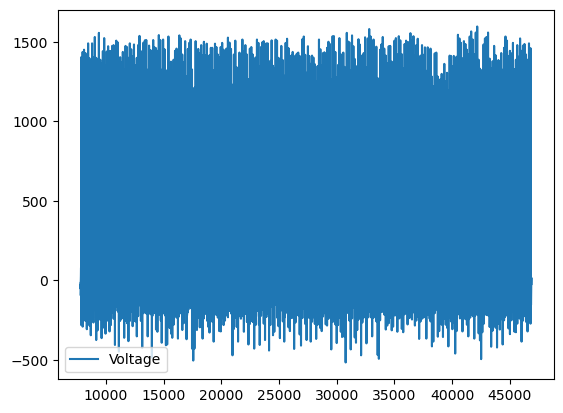

In [7]:
## 查看截取后数据
df_trim.plot()

In [8]:
# 方便在 VS code 当中查看缩放数据
%matplotlib ipympl 

<Axes: >

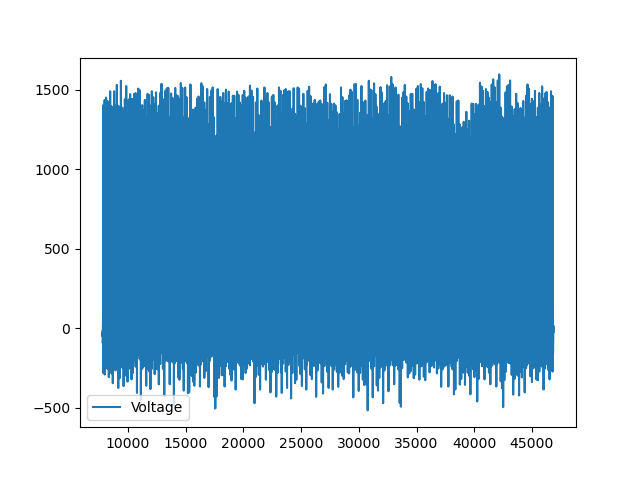

In [9]:
## 查看截取后数据
df_trim.plot()

<Axes: >

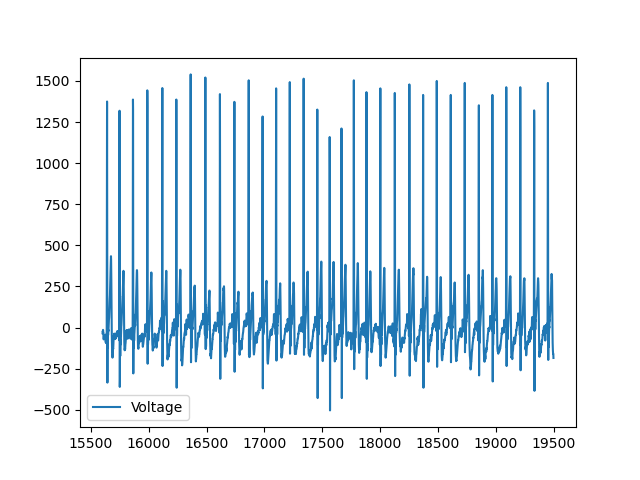

In [10]:
## 查看 30 秒内的心率数据
df_trim[7800:11700].plot() # 30秒内心脏跳动 33 次，心率为 66 次


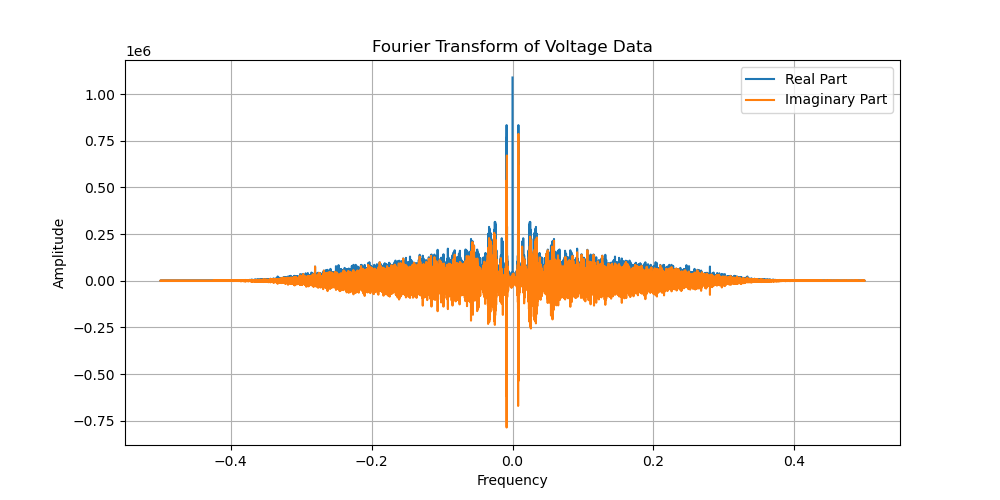

In [13]:
# 进行傅立叶变化
import pandas as pd
from scipy.fft import fft
import numpy as np
import matplotlib.pyplot as plt

# 假设 df_trim 是你的数据框，并且有一列 'Voltage' 包含电压数据
# 例如：
# df_trim = pd.read_csv('your_data.csv')  # 读取你的数据文件

# 这里我们用示例数据创建 df_trim
"""
data = {
    'Voltage': np.sin(2 * np.pi * 5 * np.linspace(0, 1, 500)) + np.sin(2 * np.pi * 10 * np.linspace(0, 1, 500))
}
df_trim = pd.DataFrame(data)
"""

# 对电压数据进行傅立叶变换
voltage_data = df_trim['Voltage'].values
fourier_transformed = fft(voltage_data)

# 计算实部和虚部
real_part = np.abs(fourier_transformed)
imag_part = np.imag(fourier_transformed)

# 获取频率轴
frequency = np.fft.fftfreq(len(voltage_data))

# 绘制频谱图
plt.figure(figsize=(10, 5))
plt.plot(frequency, real_part, label='Real Part')  # 绘制实部
plt.plot(frequency, imag_part, label='Imaginary Part')  # 绘制虚部
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.title('Fourier Transform of Voltage Data')
plt.legend()
plt.grid(True)
plt.show()